# НХЛ и ЧМ по хоккею: влияние десанта из НХЛ на результаты

## Гипотезы
1. Чем больше НХЛ-игроков в составе — тем выше место на ЧМ
2. Дата окончания 1-го раунда плей-офф НХЛ влияет на силу составов Канады/США

## Данные
- Период: 2016–2026 (без 2020)
- Составы ЧМ: Wikipedia (16 сборных × 10 лет = ~4000 игроков)
- Результаты ЧМ: собраны вручную
- Даты плей-офф НХЛ: Hockey Reference

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
from io import StringIO
import re
import time

## 1. Загрузка данных
Загружаем результаты чемпионатов мира и составы сборных за 2016–2026.

In [2]:
df_results = pd.read_excel('tournament_results.xlsx')
print(f'Результаты ЧМ: {len(df_results)} строк')
df_results.head()

Результаты ЧМ: 80 строк


,year,team,place
0,2016,Canada,1
1,2016,Finland,2
2,2016,Russia,3
3,2016,USA,4
4,2016,Czech Republic,5


## 2. Составы ЧМ — очистка и определение NHL-игроков
Загружаем составы всех сборных за каждый год. Для каждого игрока определяем `is_nhl` — играл ли он в НХЛ в том же сезоне, сравнивая с базой игроков НХЛ.

In [3]:
years = [2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]
all_data = []

for year in years:
    df_wc = pd.read_excel(f'wc{year}.xlsx')
    df_wc['Name'] = df_wc['Name'].str.replace(r'\s*[–-]\s*[AC]$', '', regex=True).str.strip()
    df_wc = df_wc[['Name', 'National team']]
    df_wc.columns = ['name', 'country']
    df_wc['country'] = df_wc['country'].str.strip()
    
    df_nhl = pd.read_csv(f'nhl_{year}.csv', header=1)
    nhl_names = set(df_nhl['Player'].str.strip())
    
    df_wc['is_nhl'] = df_wc['name'].isin(nhl_names).astype(int)
    df_wc['year'] = year
    all_data.append(df_wc)

df_all = pd.concat(all_data, ignore_index=True)
df_all = df_all.dropna(subset=['country'])
df_all['country'] = df_all['country'].replace('United States', 'USA')

print(f'Всего игроков: {len(df_all)}')
print(f'НХЛ-игроков: {df_all["is_nhl"].sum()}')
print(f'Доля НХЛ: {df_all["is_nhl"].mean():.1%}')

Всего игроков: 4060
НХЛ-игроков: 911
Доля НХЛ: 22.4%


## 3. Гипотеза 1 — NHL% vs место на ЧМ
**Гипотеза:** чем больше НХЛ-игроков в составе сборной, тем выше она финиширует на ЧМ.

Считаем долю НХЛ-игроков для каждой сборной за каждый год и объединяем с результатами турнира.

In [4]:
df_nhl_pct = df_all.groupby(['year', 'country'])['is_nhl'].mean().reset_index()
df_nhl_pct.columns = ['year', 'country', 'nhl_pct']

df_merged = df_results.merge(df_nhl_pct, left_on=['year', 'team'], right_on=['year', 'country'])
df_merged = df_merged.drop(columns=['country'])

correlation = df_merged['nhl_pct'].corr(df_merged['place'])
print(f'Корреляция NHL% и места: {correlation:.3f}')
print(f'Строк в датасете: {len(df_merged)}')
df_merged.head()

Корреляция NHL% и места: -0.387
Строк в датасете: 80


,year,team,place,nhl_pct
0,2016,Canada,1,0.956522
1,2016,Finland,2,0.400000
2,2016,Russia,3,0.320000
3,2016,USA,4,0.750000
4,2016,Czech Republic,5,0.160000


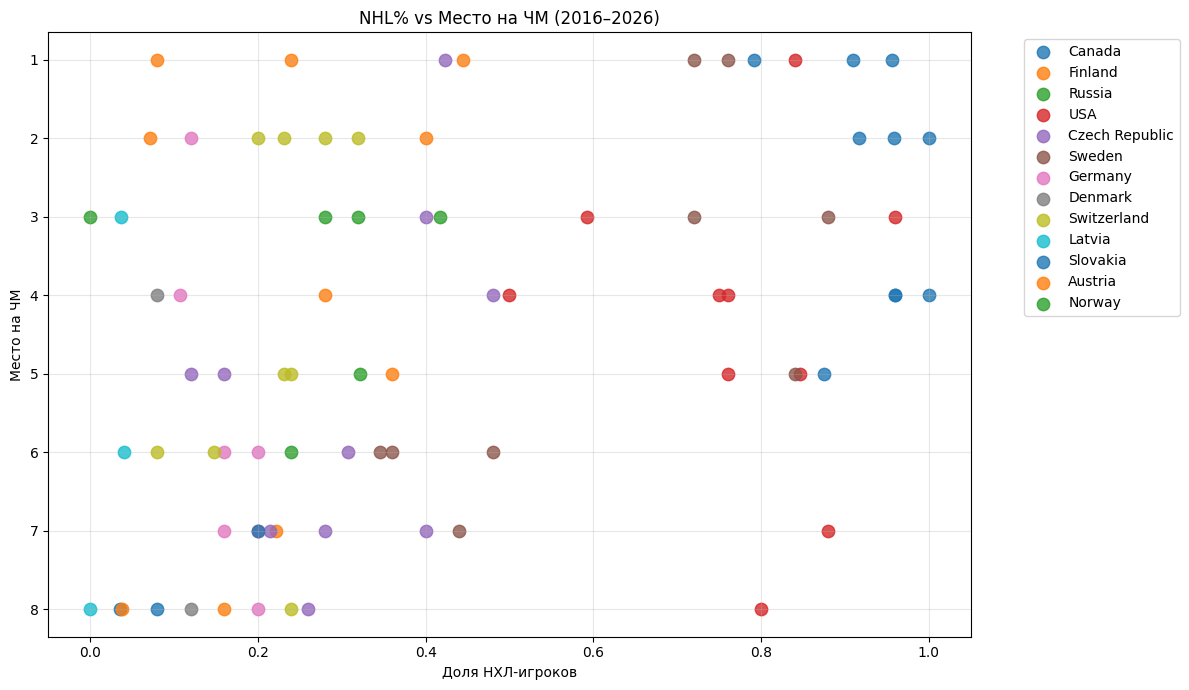

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

teams = df_merged['team'].unique()
colors = plt.cm.tab10.colors

for i, team in enumerate(teams):
    subset = df_merged[df_merged['team'] == team]
    ax.scatter(subset['nhl_pct'], subset['place'], 
               label=team, color=colors[i % 10], s=80, alpha=0.8)

ax.set_xlabel('Доля НХЛ-игроков')
ax.set_ylabel('Место на ЧМ')
ax.set_title('NHL% vs Место на ЧМ (2016–2026)')
ax.invert_yaxis()
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:** корреляция -0.387 — умеренная отрицательная связь. Чем больше НХЛ-игроков в составе, тем выше место на ЧМ. Гипотеза **подтверждается**.

## 4. Гипотеза 2 — дата окончания 1-го раунда плей-офф vs NHL%
**Гипотеза:** чем позже заканчивается 1-й раунд Кубка Стэнли, тем меньше НХЛ-игроков успевает приехать на ЧМ (актуально для Канады и США).

In [8]:
first_round_end = {
    2016: '2016-04-27', 2017: '2017-04-26',
    2018: '2018-04-25', 2019: '2019-04-23',
    2021: '2021-05-28', 2022: '2022-05-16',
    2023: '2023-05-01', 2024: '2024-05-14',
    2025: '2025-05-12', 2026: '2026-05-03',
}

df_rounds = pd.DataFrame(list(first_round_end.items()), columns=['year', 'round1_end'])
df_rounds['round1_end'] = pd.to_datetime(df_rounds['round1_end'])
df_rounds['round1_day'] = df_rounds['round1_end'].dt.dayofyear

df_canada_usa = df_merged[df_merged['team'].isin(['Canada', 'USA'])]
df_canada_usa = df_canada_usa.merge(df_rounds, on='year')

corr = df_canada_usa['round1_day'].corr(df_canada_usa['nhl_pct'])
print(f'Корреляция даты 1-го раунда и NHL%: {corr:.3f}')

Корреляция даты 1-го раунда и NHL%: -0.336


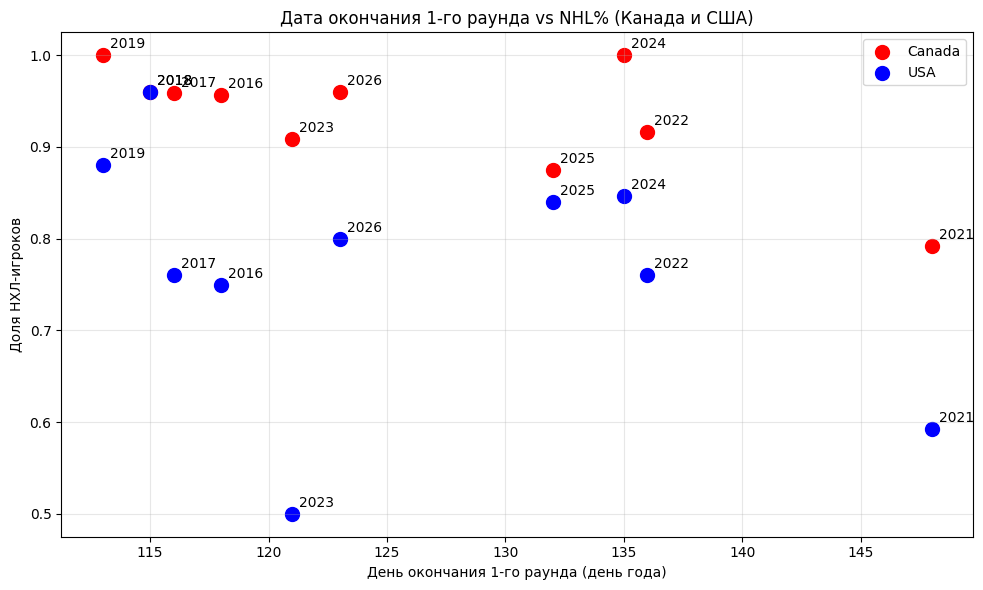

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for team, color in [('Canada', 'red'), ('USA', 'blue')]:
    subset = df_canada_usa[df_canada_usa['team'] == team]
    ax.scatter(subset['round1_day'], subset['nhl_pct'],
               label=team, color=color, s=100)
    for _, row in subset.iterrows():
        ax.annotate(str(row['year']),
                   (row['round1_day'], row['nhl_pct']),
                   textcoords='offset points', xytext=(5, 5))

ax.set_xlabel('День окончания 1-го раунда (день года)')
ax.set_ylabel('Доля НХЛ-игроков')
ax.set_title('Дата окончания 1-го раунда vs NHL% (Канада и США)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:** корреляция -0.336 — умеренная отрицательная связь. В 2021 году 1-й раунд закончился 28 мая (день 148) из-за COVID, и NHL% Канады упал до 0.79, США до 0.59 — минимум за все годы. Гипотеза **подтверждается**.

## 5. Тренды по годам — топ сборные
Динамика доли НХЛ-игроков по годам для ключевых сборных.

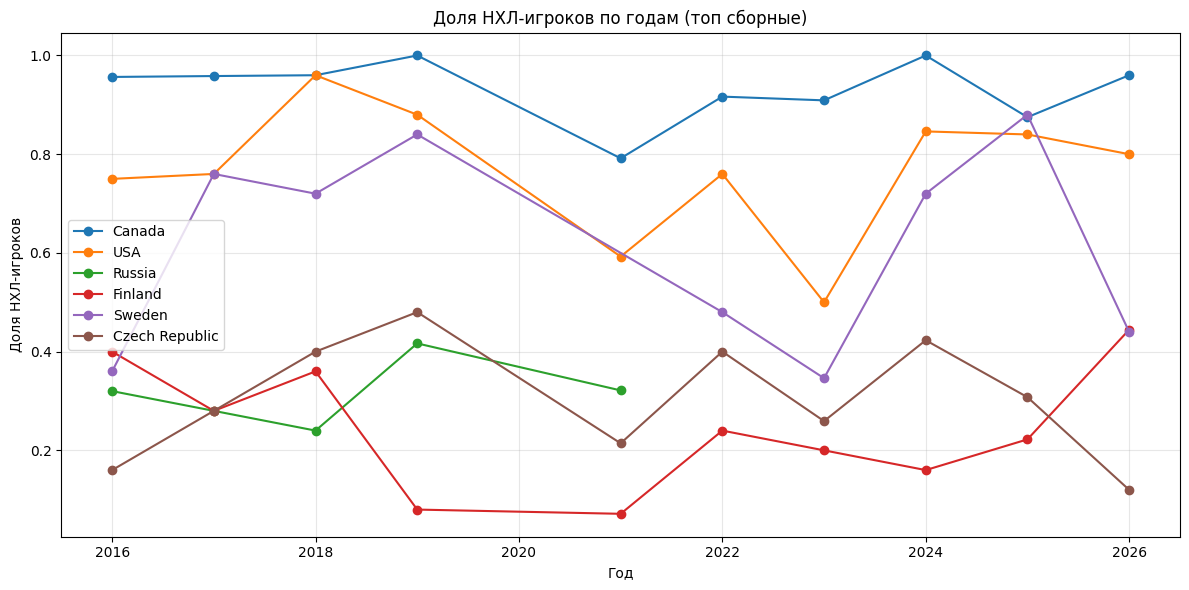

In [11]:
top_teams = ['Canada', 'USA', 'Russia', 'Finland', 'Sweden', 'Czech Republic']

fig, ax = plt.subplots(figsize=(12, 6))

for team in top_teams:
    subset = df_merged[df_merged['team'] == team].sort_values('year')
    ax.plot(subset['year'], subset['nhl_pct'], marker='o', label=team)

ax.set_xlabel('Год')
ax.set_ylabel('Доля НХЛ-игроков')
ax.set_title('Доля НХЛ-игроков по годам (топ сборные)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Наблюдения:**
- Россия и Беларусь отстранены от ЧМ после 2022 года — данные обрываются
- Канада и США стабильно выше всех по NHL%, с провалом в 2021 (сезон сдвинут из-за COVID)
- Финляндия с относительно низким NHL% регулярно попадает в топ — интересный аутлаер

## 6. Итоговые выводы

### Гипотеза 1 ✅ Подтверждается
Корреляция между долей НХЛ-игроков и местом на ЧМ составила **-0.387**. 
Чем больше НХЛ-игроков в составе — тем выше место на турнире.

### Гипотеза 2 ✅ Подтверждается  
Корреляция между датой окончания 1-го раунда плей-офф и NHL% составила **-0.336**.
Чем позже заканчивается 1-й раунд — тем меньше НХЛ-игроков успевает приехать на ЧМ.
Наиболее яркий пример — 2021 год (COVID): 1-й раунд закончился 28 мая, NHL% Канады упал до 0.79, США до 0.59.

### Ограничения
- Корреляция не равна причинно-следственной связи
- Финляндия — аутлаер: низкий NHL% но стабильно высокие результаты
- Россия исключена из анализа после 2022 года
- Выборка небольшая: 80 наблюдений за 10 лет